In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# PART 1: The "Prunable" Linear Layer

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Standard Weight and Bias parameters
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)

        # Learnable Gate Scores: Same shape as weight tensor
        # This will be transformed by Sigmoid into (0, 1) gates
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        self.reset_parameters()

    def reset_parameters(self):
        # Kaiming initialization for better gradient flow in deep networks
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / np.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

        # Initialize gate_scores to 2.0 (Sigmoid(2.0) ≈ 0.88)
        # This ensures weights are active at the start of training
        nn.init.constant_(self.gate_scores, 2.0)

    def forward(self, x):
        # Transform gate_scores into soft-gates between 0 and 1
        gates = torch.sigmoid(self.gate_scores)

        # Apply pruning via element-wise multiplication (Hadamard product)
        pruned_weights = self.weight * gates

        # Standard linear layer operation using pruned weights
        return F.linear(x, pruned_weights, self.bias)

    def get_sparsity_loss(self):
        """Returns the L1 norm of the gates (sum of absolute values)."""
        return torch.sum(torch.sigmoid(self.gate_scores))

In [3]:
# PART 2: The Neural Network Architecture

class SelfPruningCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SelfPruningCNN, self).__init__()
        # Simple feature extractor (standard Conv layers)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # Classifier using our custom PrunableLinear layers
        # CIFAR-10 image size 32x32 -> MaxPool x2 results in 8x8 spatial size
        self.classifier = nn.Sequential(
            PrunableLinear(64 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            PrunableLinear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def get_total_sparsity_penalty(self):
        """Aggregates sparsity loss from all prunable layers."""
        penalty = 0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                penalty += module.get_sparsity_loss()
        return penalty

In [4]:
# PART 3: Training and Evaluation Engine

def train_and_eval(lambda_val, epochs=10, device='cuda'):
    # Data preprocessing
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)

    model = SelfPruningCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    print(f"\n[Training] Lambda: {lambda_val} | Device: {device}")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # Total Loss = CrossEntropy + Lambda * (L1 of Gates)
            ce_loss = criterion(outputs, labels)
            sparsity_penalty = model.get_total_sparsity_penalty()
            loss = ce_loss + lambda_val * sparsity_penalty

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {running_loss/len(train_loader):.4f}")

    # --- Final Metrics ---
    model.eval()
    correct, total = 0, 0
    all_gates = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Collect gate values for sparsity calculation and plotting
        for m in model.modules():
            if isinstance(m, PrunableLinear):
                all_gates.append(torch.sigmoid(m.gate_scores).cpu().flatten())

    acc = 100 * correct / total
    combined_gates = torch.cat(all_gates).numpy()
    # Sparsity: Percentage of gates below a threshold (1e-2)
    sparsity_pct = 100 * (combined_gates < 0.01).sum() / combined_gates.size

    return acc, sparsity_pct, combined_gates


[Training] Lambda: 1e-06 | Device: cuda
Epoch 1/10 | Avg Loss: 3.1160
Epoch 2/10 | Avg Loss: 2.6797
Epoch 3/10 | Avg Loss: 2.4492
Epoch 4/10 | Avg Loss: 2.2206
Epoch 5/10 | Avg Loss: 1.9826
Epoch 6/10 | Avg Loss: 1.7494
Epoch 7/10 | Avg Loss: 1.5260
Epoch 8/10 | Avg Loss: 1.3316
Epoch 9/10 | Avg Loss: 1.1590
Epoch 10/10 | Avg Loss: 1.0090

[Training] Lambda: 5e-05 | Device: cuda
Epoch 1/10 | Avg Loss: 91.5118
Epoch 2/10 | Avg Loss: 84.7041
Epoch 3/10 | Avg Loss: 75.5851
Epoch 4/10 | Avg Loss: 64.4445
Epoch 5/10 | Avg Loss: 52.7992
Epoch 6/10 | Avg Loss: 42.2390
Epoch 7/10 | Avg Loss: 33.5869
Epoch 8/10 | Avg Loss: 26.8584
Epoch 9/10 | Avg Loss: 21.7200
Epoch 10/10 | Avg Loss: 17.7993

[Training] Lambda: 0.0001 | Device: cuda
Epoch 1/10 | Avg Loss: 181.5467
Epoch 2/10 | Avg Loss: 168.0618
Epoch 3/10 | Avg Loss: 149.5139
Epoch 4/10 | Avg Loss: 126.7316
Epoch 5/10 | Avg Loss: 102.9108
Epoch 6/10 | Avg Loss: 81.3905
Epoch 7/10 | Avg Loss: 63.8486
Epoch 8/10 | Avg Loss: 50.3044
Epoch 9/10 

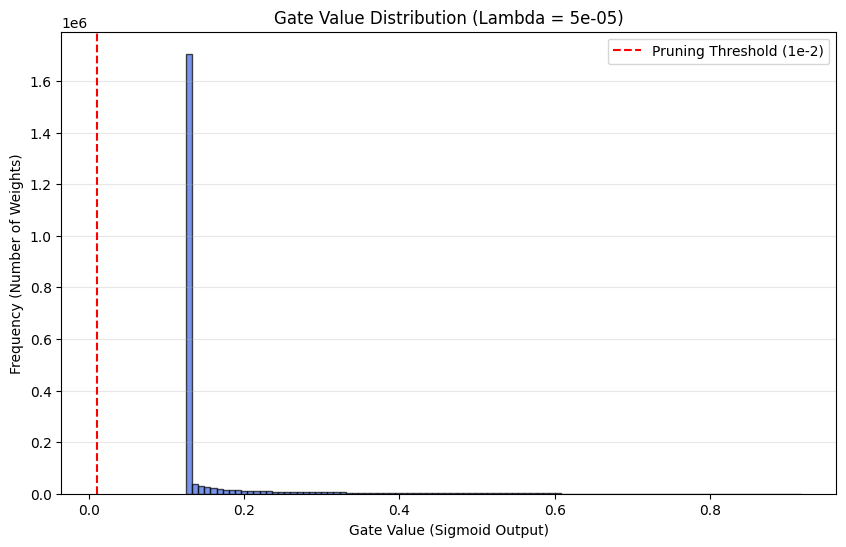

In [5]:
# PART 4: Hyperparameter Comparison & Results
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Lambda values to test (Low, Medium, High sparsity pressure)
    lambda_list = [1e-6, 5e-5, 1e-4]
    results_history = []

    for l in lambda_list:
        accuracy, sparsity, gates = train_and_eval(l, epochs=10, device=device)
        results_history.append({
            'lambda': l,
            'accuracy': accuracy,
            'sparsity': sparsity,
            'gates': gates
        })

    # Display Results Summary Table
    print("\n" + "="*50)
    print(f"{'Lambda':<12} | {'Test Acc (%)':<15} | {'Sparsity (%)':<15}")
    print("-" * 50)
    for res in results_history:
        print(f"{res['lambda']:<12} | {res['accuracy']:<15.2f} | {res['sparsity']:<15.2f}")
    print("="*50)

    # Plot Distribution for the Medium Lambda Model
    # A successful run will show a large spike at 0 and a cluster at 1.
    target_idx = 1 # Medium Lambda
    plt.figure(figsize=(10, 6))
    plt.hist(results_history[target_idx]['gates'], bins=100, color='royalblue', alpha=0.7, edgecolor='black')
    plt.axvline(0.01, color='red', linestyle='--', label='Pruning Threshold (1e-2)')
    plt.title(f"Gate Value Distribution (Lambda = {results_history[target_idx]['lambda']})")
    plt.xlabel("Gate Value (Sigmoid Output)")
    plt.ylabel("Frequency (Number of Weights)")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('gate_distribution.png')
    plt.show()